# 📊 Étape 2 — Exploration & Nettoyage des données (EDA)
## Projet : Analyse & Prédiction des flux de mobilité IDFM

---

### Pourquoi ce notebook ?

Avant de construire des modèles ML, on doit **comprendre les données**. Un modèle entraîné sur des données mal comprises donnera de mauvais résultats même si l'algorithme est excellent.

Ce notebook répond à 4 questions fondamentales :
1. **Analyse descriptive** — À quoi ressemblent mes données ? Y a-t-il des anomalies ?
2. **Analyse temporelle** — Comment le trafic évolue-t-il dans le temps ?
3. **Analyse des titres** — Qui utilise quoi comme titre de transport ?
4. **Traitement des NON DEFINIS** — Comment gérer les titres non identifiés ?

### Données utilisées
- **Source** : Base MySQL `idfm_mobility`, table `validations`
- **Volume** : 468 226 lignes
- **Période** : 1er juillet 2025 → 30 septembre 2025 (92 jours)
- **Arrêts** : 772 arrêts Île-de-France
- **Catégories de titres** : 7 (Forfait Navigo, Imagine R, NON DEFINI...)

---
## 🔧 Cellule 0 — Imports et connexion MySQL

### Pourquoi cette cellule ?
Avant tout, on importe les bibliothèques dont on a besoin et on se connecte à MySQL.
On lit les données depuis MySQL (pas depuis le CSV) car c'est là que vivent nos données nettoyées.

### Les bibliothèques :
- **pandas** : manipuler les données sous forme de tableaux (DataFrames)
- **matplotlib** : créer des graphiques statiques
- **seaborn** : graphiques statistiques plus élaborés (heatmaps, distributions)
- **plotly** : graphiques interactifs (on peut zoomer, survoler avec la souris)
- **sqlalchemy** : connexion Python → MySQL
- **dotenv** : lire le fichier .env pour le mot de passe MySQL

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

# Style global des graphiques matplotlib
# 'seaborn-v0_8' = style propre et professionnel
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')  # palette de couleurs harmonieuse

# Taille par defaut des figures matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print('OK Imports OK')

OK Imports OK


In [3]:
# ============================================================
# CONNEXION MYSQL
# ============================================================
# On charge les variables du fichier .env
# Le .env contient le mot de passe MySQL - on ne le met jamais en dur dans le code
load_dotenv()

DB_USER     = os.getenv('DB_USER', 'root')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_HOST     = os.getenv('DB_HOST', 'localhost')
DB_PORT     = os.getenv('DB_PORT', '3306')
DB_NAME     = os.getenv('DB_NAME', 'idfm_mobility')

engine = create_engine(
    f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

# ============================================================
# CHARGEMENT DES DONNEES DEPUIS MYSQL
# ============================================================
# pd.read_sql envoie une requete SQL a MySQL et retourne directement
# un DataFrame Pandas - c'est le pont entre SQL et Python
print('Chargement des donnees depuis MySQL...')

df = pd.read_sql('SELECT * FROM validations', con=engine)

# Convertir JOUR en type datetime Python
# POURQUOI : pour pouvoir faire des calculs de dates
# (extraire le mois, le jour de semaine, etc.)
df['JOUR'] = pd.to_datetime(df['JOUR'])

print(f'OK Donnees chargees : {len(df):,} lignes, {len(df.columns)} colonnes')
print(f'Periode : {df["JOUR"].min().date()} -> {df["JOUR"].max().date()}')
print(f'Nombre d arrets : {df["LIBELLE_ARRET"].nunique()}')
print(f'Categories de titres : {df["CATEGORIE_TITRE"].nunique()}')
print(f'Categories : {df["CATEGORIE_TITRE"].unique().tolist()}')

Chargement des donnees depuis MySQL...
OK Donnees chargees : 468,226 lignes, 8 colonnes
Periode : 2025-07-01 -> 2025-09-30
Nombre d arrets : 772
Categories de titres : 7
Categories : ['Autres titres', 'NON DEFINI', 'Forfait Navigo', 'Forfaits courts', 'Imagine R', 'Contrat Solidarité Transport', 'Amethyste']


---
## PARTIE 1 — Analyse descriptive

### Pourquoi ?
Avant de faire quoi que ce soit, on regarde les donnees brutes :
- A quoi ressemble la distribution des validations ?
- Y a-t-il des valeurs manquantes ou des doublons ?
- Quels sont les arrets les plus frequentes ?
- Comment se repartissent les categories de titres ?

In [4]:
# ============================================================
# APERCU GENERAL DES DONNEES
# ============================================================
# .head() affiche les 5 premieres lignes
# Permet de verifier visuellement que les donnees ont bien ete chargees
print('5 premieres lignes :')
display(df.head())

print('\nTypes de donnees de chaque colonne :')
print(df.dtypes)

# .describe() calcule automatiquement les statistiques de base
# pour toutes les colonnes numeriques :
# count = nombre de valeurs
# mean  = moyenne
# std   = ecart-type (mesure la dispersion autour de la moyenne)
# min/max = valeurs extremes
# 25%/50%/75% = quartiles
print('\nStatistiques descriptives :')
display(df.describe())

5 premieres lignes :


,JOUR,CODE_STIF_TRNS,CODE_STIF_RES,CODE_STIF_ARRET,ID_ZDC,LIBELLE_ARRET,CATEGORIE_TITRE,NB_VALD
0,2025-07-18,800,803,424,59761,LARDY,Autres titres,1
1,2025-07-18,800,803,424,59761,LARDY,NON DEFINI,1
2,2025-07-18,800,803,444,70064,ARDOINES,Forfait Navigo,1586
3,2025-07-18,800,803,450,72219,GRESILLONS,Forfaits courts,582
4,2025-07-18,800,803,454,69662,SAULES,Forfait Navigo,690



Types de donnees de chaque colonne :
JOUR               datetime64[ns]
CODE_STIF_TRNS              int64
CODE_STIF_RES              object
CODE_STIF_ARRET            object
ID_ZDC                      int64
LIBELLE_ARRET              object
CATEGORIE_TITRE            object
NB_VALD                     int64
dtype: object

Statistiques descriptives :


,JOUR,CODE_STIF_TRNS,ID_ZDC,NB_VALD
count,468226,468226.000000,468226.000000,468226.000000
mean,2025-08-15 18:52:20.360423936,502.223136,92471.013224,1032.908781
min,2025-07-01 00:00:00,100.000000,0.000000,1.000000
25%,2025-07-23 00:00:00,100.000000,66491.000000,40.000000
50%,2025-08-16 00:00:00,800.000000,71147.000000,187.000000
75%,2025-09-08 00:00:00,800.000000,71920.000000,906.000000
max,2025-09-30 00:00:00,810.000000,492980.000000,92442.000000
std,NaN,347.172322,93581.203767,2843.231439


In [5]:
# ============================================================
# VALEURS MANQUANTES ET DOUBLONS
# ============================================================
# POURQUOI :
# - Des valeurs manquantes dans les features = modele ML qui plante
# - Des doublons = les donnees sont comptees deux fois = resultats faux

print('QUALITE DES DONNEES')
print('=' * 50)

# Valeurs manquantes par colonne
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
qualite = pd.DataFrame({
    'Valeurs manquantes': nulls,
    'Pourcentage (%)': nulls_pct
})
print('\nValeurs manquantes par colonne :')
display(qualite)

# Doublons
# Un doublon = une ligne identique a une autre sur TOUTES les colonnes
nb_doublons = df.duplicated().sum()
print(f'\nNombre de doublons : {nb_doublons:,}')

if nb_doublons == 0 and nulls.sum() == 0:
    print('OK Donnees propres : aucune valeur manquante, aucun doublon')
else:
    print('ATTENTION : des problemes de qualite ont ete detectes')

QUALITE DES DONNEES

Valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage (%)
JOUR,0,0.0
CODE_STIF_TRNS,0,0.0
CODE_STIF_RES,0,0.0
CODE_STIF_ARRET,0,0.0
ID_ZDC,0,0.0
LIBELLE_ARRET,0,0.0
CATEGORIE_TITRE,0,0.0
NB_VALD,0,0.0



Nombre de doublons : 0
OK Donnees propres : aucune valeur manquante, aucun doublon


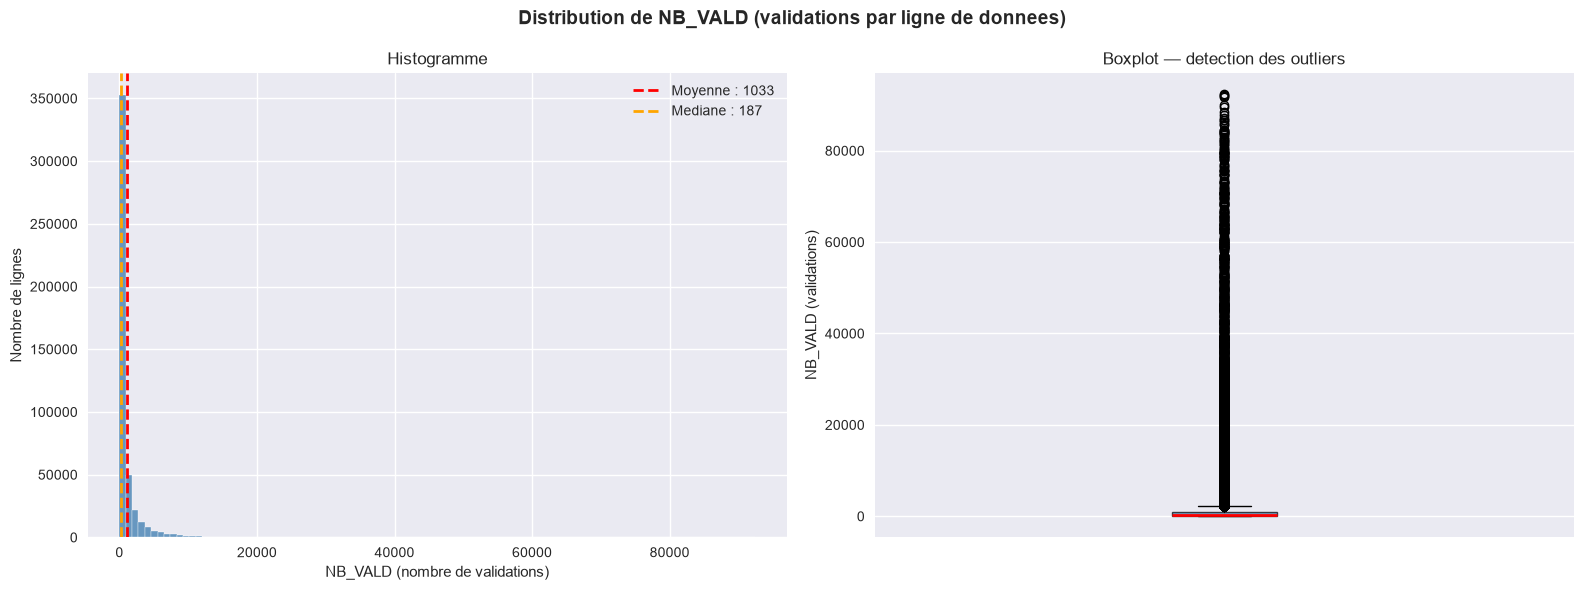

Moyenne  : 1032.9 validations par ligne
Mediane  : 187.0 validations par ligne
Maximum  : 92,442 validations
Minimum  : 1 validations

Si moyenne >> mediane : distribution asymetrique
Quelques grands arrets tirent la moyenne vers le haut


In [6]:
# ============================================================
# DISTRIBUTION DE NB_VALD — Histogramme + Boxplot
# ============================================================
# POURQUOI CES DEUX GRAPHIQUES ?
#
# L'HISTOGRAMME montre la forme de la distribution :
# - L'axe X = les valeurs de NB_VALD (0, 100, 1000, ...)
# - L'axe Y = combien de lignes ont cette valeur
# - On s'attend a voir une forme en cloche asymetrique :
#   beaucoup de petits arrets a gauche, quelques grands a droite
#
# LE BOXPLOT montre les valeurs extremes :
# - La boite = 50% des donnees (entre Q1 et Q3)
# - La ligne au milieu = la mediane
# - Les points isoles au-dessus = les outliers (Saint-Lazare, Chatelet...)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution de NB_VALD (validations par ligne de donnees)',
             fontsize=14, fontweight='bold')

# --- Histogramme ---
axes[0].hist(df['NB_VALD'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('NB_VALD (nombre de validations)')
axes[0].set_ylabel('Nombre de lignes')
axes[0].set_title('Histogramme')
# Ligne rouge = moyenne
axes[0].axvline(df['NB_VALD'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Moyenne : {df["NB_VALD"].mean():.0f}')
# Ligne orange = mediane
axes[0].axvline(df['NB_VALD'].median(), color='orange', linestyle='--',
                linewidth=2, label=f'Mediane : {df["NB_VALD"].median():.0f}')
axes[0].legend()

# --- Boxplot ---
axes[1].boxplot(df['NB_VALD'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('NB_VALD (validations)')
axes[1].set_title('Boxplot — detection des outliers')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f'Moyenne  : {df["NB_VALD"].mean():.1f} validations par ligne')
print(f'Mediane  : {df["NB_VALD"].median():.1f} validations par ligne')
print(f'Maximum  : {df["NB_VALD"].max():,} validations')
print(f'Minimum  : {df["NB_VALD"].min()} validations')
print(f'\nSi moyenne >> mediane : distribution asymetrique')
print(f'Quelques grands arrets tirent la moyenne vers le haut')

In [7]:
# ============================================================
# TOP 20 ARRETS PAR VOLUME TOTAL
# ============================================================
# POURQUOI : identifier les arrets les plus importants
# Ce sont eux qui auront le plus d'impact dans nos modeles ML
#
# groupby = regrouper par arret
# sum     = additionner NB_VALD de toutes les lignes de cet arret
# nlargest(20) = garder les 20 plus grands

top20 = (df.groupby('LIBELLE_ARRET')['NB_VALD']
           .sum()
           .nlargest(20)
           .reset_index()
           .rename(columns={'NB_VALD': 'total_validations'}))

fig = px.bar(
    top20.sort_values('total_validations'),
    x='total_validations',
    y='LIBELLE_ARRET',
    orientation='h',
    title='TOP 20 Arrets les plus frequentes (total sur 92 jours)',
    labels={'total_validations': 'Total validations', 'LIBELLE_ARRET': 'Arret'},
    color='total_validations',
    color_continuous_scale='Blues',
    text='total_validations'
)
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(height=700, showlegend=False)
fig.show()

top20['total_millions'] = (top20['total_validations'] / 1_000_000).round(2)
print('\nTOP 20 en tableau :')
display(top20.sort_values('total_validations', ascending=False)
             .rename(columns={'total_millions': 'total (millions)'}))


TOP 20 en tableau :


,LIBELLE_ARRET,total_validations,total (millions)
0,SAINT-LAZARE,18197521,18.20
1,CHATELET,12633408,12.63
2,GARE DE LYON,11918345,11.92
3,MONTPARNASSE,10813265,10.81
4,LA DEFENSE,9168948,9.17
5,GARE DU NORD,8448309,8.45
6,GARE DE L'EST,7319624,7.32
7,CH.D.G.ETOILE,4404270,4.40
8,LES HALLES,4002731,4.00
9,REPUBLIQUE,3620872,3.62


In [8]:
# ============================================================
# REPARTITION DES CATEGORIES DE TITRES — Donut chart
# ============================================================
# POURQUOI : comprendre qui utilise quel titre
# Forfait Navigo = abonnement mensuel standard (travailleurs)
# Imagine R      = abonnement etudiant/lyceen
# Amethyste      = abonnement senior/handicap
# Forfaits courts = tickets a l'unite (touristes, occasionnels)
# NON DEFINI     = titre non reconnu (fraude potentielle)
#
# On utilise un DONUT CHART (camembert avec trou au centre)
# car il est plus lisible qu'un camembert plein quand il y a
# beaucoup de categories

categories = (df.groupby('CATEGORIE_TITRE')['NB_VALD']
                .sum()
                .reset_index()
                .sort_values('NB_VALD', ascending=False))

categories['pct'] = (categories['NB_VALD'] / categories['NB_VALD'].sum() * 100).round(1)

fig = px.pie(
    categories,
    values='NB_VALD',
    names='CATEGORIE_TITRE',
    title='Repartition des validations par categorie de titre',
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.update_layout(height=550)
fig.show()

print('\nDetail par categorie :')
display(categories.rename(columns={
    'NB_VALD': 'total_validations',
    'pct': 'part (%)'
}).reset_index(drop=True))


Detail par categorie :


,CATEGORIE_TITRE,total_validations,part (%)
0,Forfait Navigo,251434647,52.0
1,Forfaits courts,90115054,18.6
2,Imagine R,69114429,14.3
3,Contrat Solidarité Transport,52913860,10.9
4,Amethyste,9382161,1.9
5,NON DEFINI,6591009,1.4
6,Autres titres,4083587,0.8


In [9]:
# ============================================================
# EVOLUTION DU TRAFIC TOTAL SUR LES 92 JOURS
# ============================================================
# POURQUOI : voir la tendance generale sur la periode
# On s'attend a voir :
# - Des creux reguliers les week-ends (toutes les 7 jours)
# - Un creux autour du 14 juillet (jour ferie)
# - Un creux en aout (vacances d'ete)
# - Une reprise en septembre (rentree scolaire)
#
# LA MOYENNE MOBILE SUR 7 JOURS :
# C'est une technique qui calcule pour chaque jour
# la moyenne des 7 jours autour de lui
# Elle lisse les variations jour a jour pour voir la tendance de fond
# Comme regarder la meteorologie sur une semaine plutot que jour par jour

# Agréger le trafic total par jour
trafic_journalier = (df.groupby('JOUR')['NB_VALD']
                       .sum()
                       .reset_index()
                       .rename(columns={'NB_VALD': 'total_jour'}))

trafic_journalier['is_weekend'] = trafic_journalier['JOUR'].dt.dayofweek >= 5
trafic_journalier['nom_jour']   = trafic_journalier['JOUR'].dt.day_name()

# Moyenne mobile sur 7 jours (center=True = centre sur le jour courant)
trafic_journalier['rolling_mean_7j'] = (
    trafic_journalier['total_jour'].rolling(window=7, center=True).mean()
)

fig = go.Figure()

# Trafic journalier brut (ligne fine bleue)
fig.add_trace(go.Scatter(
    x=trafic_journalier['JOUR'],
    y=trafic_journalier['total_jour'],
    mode='lines',
    name='Trafic journalier',
    line=dict(color='steelblue', width=1.5),
    opacity=0.7
))

# Moyenne mobile 7 jours (ligne rouge epaisse)
fig.add_trace(go.Scatter(
    x=trafic_journalier['JOUR'],
    y=trafic_journalier['rolling_mean_7j'],
    mode='lines',
    name='Moyenne mobile 7 jours',
    line=dict(color='red', width=2.5)
))

fig.update_layout(
    title='Evolution du trafic total IDFM sur 92 jours (juil-sept 2025)',
    xaxis_title='Date',
    yaxis_title='Total validations',
    height=500,
    hovermode='x unified'
)
fig.show()

print('5 jours les plus charges :')
display(trafic_journalier.nlargest(5, 'total_jour')[['JOUR', 'nom_jour', 'total_jour']])

print('\n5 jours les plus calmes :')
display(trafic_journalier.nsmallest(5, 'total_jour')[['JOUR', 'nom_jour', 'total_jour']])

5 jours les plus charges :


,JOUR,nom_jour,total_jour
91,2025-09-30,Tuesday,7831426
86,2025-09-25,Thursday,7657161
84,2025-09-23,Tuesday,7597405
77,2025-09-16,Tuesday,7557596
78,2025-09-17,Wednesday,7515693



5 jours les plus calmes :


,JOUR,nom_jour,total_jour
47,2025-08-17,Sunday,2624591
40,2025-08-10,Sunday,2830519
54,2025-08-24,Sunday,2895748
33,2025-08-03,Sunday,2971362
61,2025-08-31,Sunday,3079279


---
## PARTIE 2 — Analyse temporelle

### Pourquoi ?
Le trafic de transport suit des **patterns temporels tres reguliers** :
- Les gens prennent le metro pour travailler → plus de trafic en semaine
- Moins de monde le week-end et les jours feries
- L'ete = vacances = moins de trafic
- La rentree en septembre = retour a la normale

Ces patterns sont exactement ce que nos features temporelles
(`is_weekend`, `jour_semaine`, `is_vacances`) vont capturer pour XGBoost.

In [10]:
# ============================================================
# TRAFIC MOYEN PAR JOUR DE LA SEMAINE
# ============================================================
# POURQUOI : quantifier la difference semaine/week-end
# et la visualiser clairement
# dt.dayofweek : 0=Lundi, 1=Mardi, ..., 6=Dimanche

ordre_jours_en = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
noms_fr = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']

trafic_journalier['dayofweek'] = trafic_journalier['JOUR'].dt.dayofweek

moy_jour = (trafic_journalier
            .groupby('nom_jour')['total_jour']
            .mean()
            .reindex(ordre_jours_en)
            .reset_index())
moy_jour['nom_fr']    = noms_fr
moy_jour['is_weekend'] = moy_jour['nom_jour'].isin(['Saturday','Sunday'])

fig = px.bar(
    moy_jour,
    x='nom_fr',
    y='total_jour',
    color='is_weekend',
    color_discrete_map={False: 'steelblue', True: 'coral'},
    title='Trafic moyen journalier par jour de la semaine',
    labels={'total_jour': 'Trafic moyen (validations)',
            'nom_fr': 'Jour',
            'is_weekend': 'Week-end'},
    text='total_jour'
)
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(height=500)
fig.show()

moy_semaine = moy_jour[~moy_jour['is_weekend']]['total_jour'].mean()
moy_weekend = moy_jour[moy_jour['is_weekend']]['total_jour'].mean()
print(f'Moyenne semaine  : {moy_semaine:,.0f} validations/jour')
print(f'Moyenne week-end : {moy_weekend:,.0f} validations/jour')
print(f'Ratio            : la semaine genere {moy_semaine/moy_weekend:.1f}x plus que le week-end')
print(f'=> Ce ratio justifie la feature is_weekend dans XGBoost')

Moyenne semaine  : 5,805,047 validations/jour
Moyenne week-end : 3,851,426 validations/jour
Ratio            : la semaine genere 1.5x plus que le week-end
=> Ce ratio justifie la feature is_weekend dans XGBoost


In [11]:
# ============================================================
# TRAFIC PAR MOIS — Juillet vs Aout vs Septembre
# ============================================================
# POURQUOI : quantifier l'effet vacances vs rentree
# Juillet = debut vacances
# Aout = plein ete (creux maximum)
# Septembre = rentree scolaire (reprise)

trafic_journalier['mois']     = trafic_journalier['JOUR'].dt.month
trafic_journalier['nom_mois'] = trafic_journalier['JOUR'].dt.strftime('%B %Y')

moy_mois = (trafic_journalier
            .groupby(['mois','nom_mois'])['total_jour']
            .agg(['mean','sum','count'])
            .reset_index()
            .sort_values('mois'))
moy_mois.columns = ['mois','nom_mois','trafic_moyen','trafic_total','nb_jours']

fig = px.bar(
    moy_mois,
    x='nom_mois',
    y='trafic_moyen',
    title='Trafic moyen journalier par mois',
    labels={'trafic_moyen': 'Trafic moyen journalier', 'nom_mois': 'Mois'},
    color='trafic_moyen',
    color_continuous_scale='RdYlGn',
    text='trafic_moyen'
)
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(height=450)
fig.show()

display(moy_mois[['nom_mois','trafic_moyen','trafic_total','nb_jours']])

,nom_mois,trafic_moyen,trafic_total,nb_jours
0,July 2025,5.454344e+06,169084666,31
1,August 2025,4.117865e+06,127653816,31
2,September 2025,6.229876e+06,186896265,30


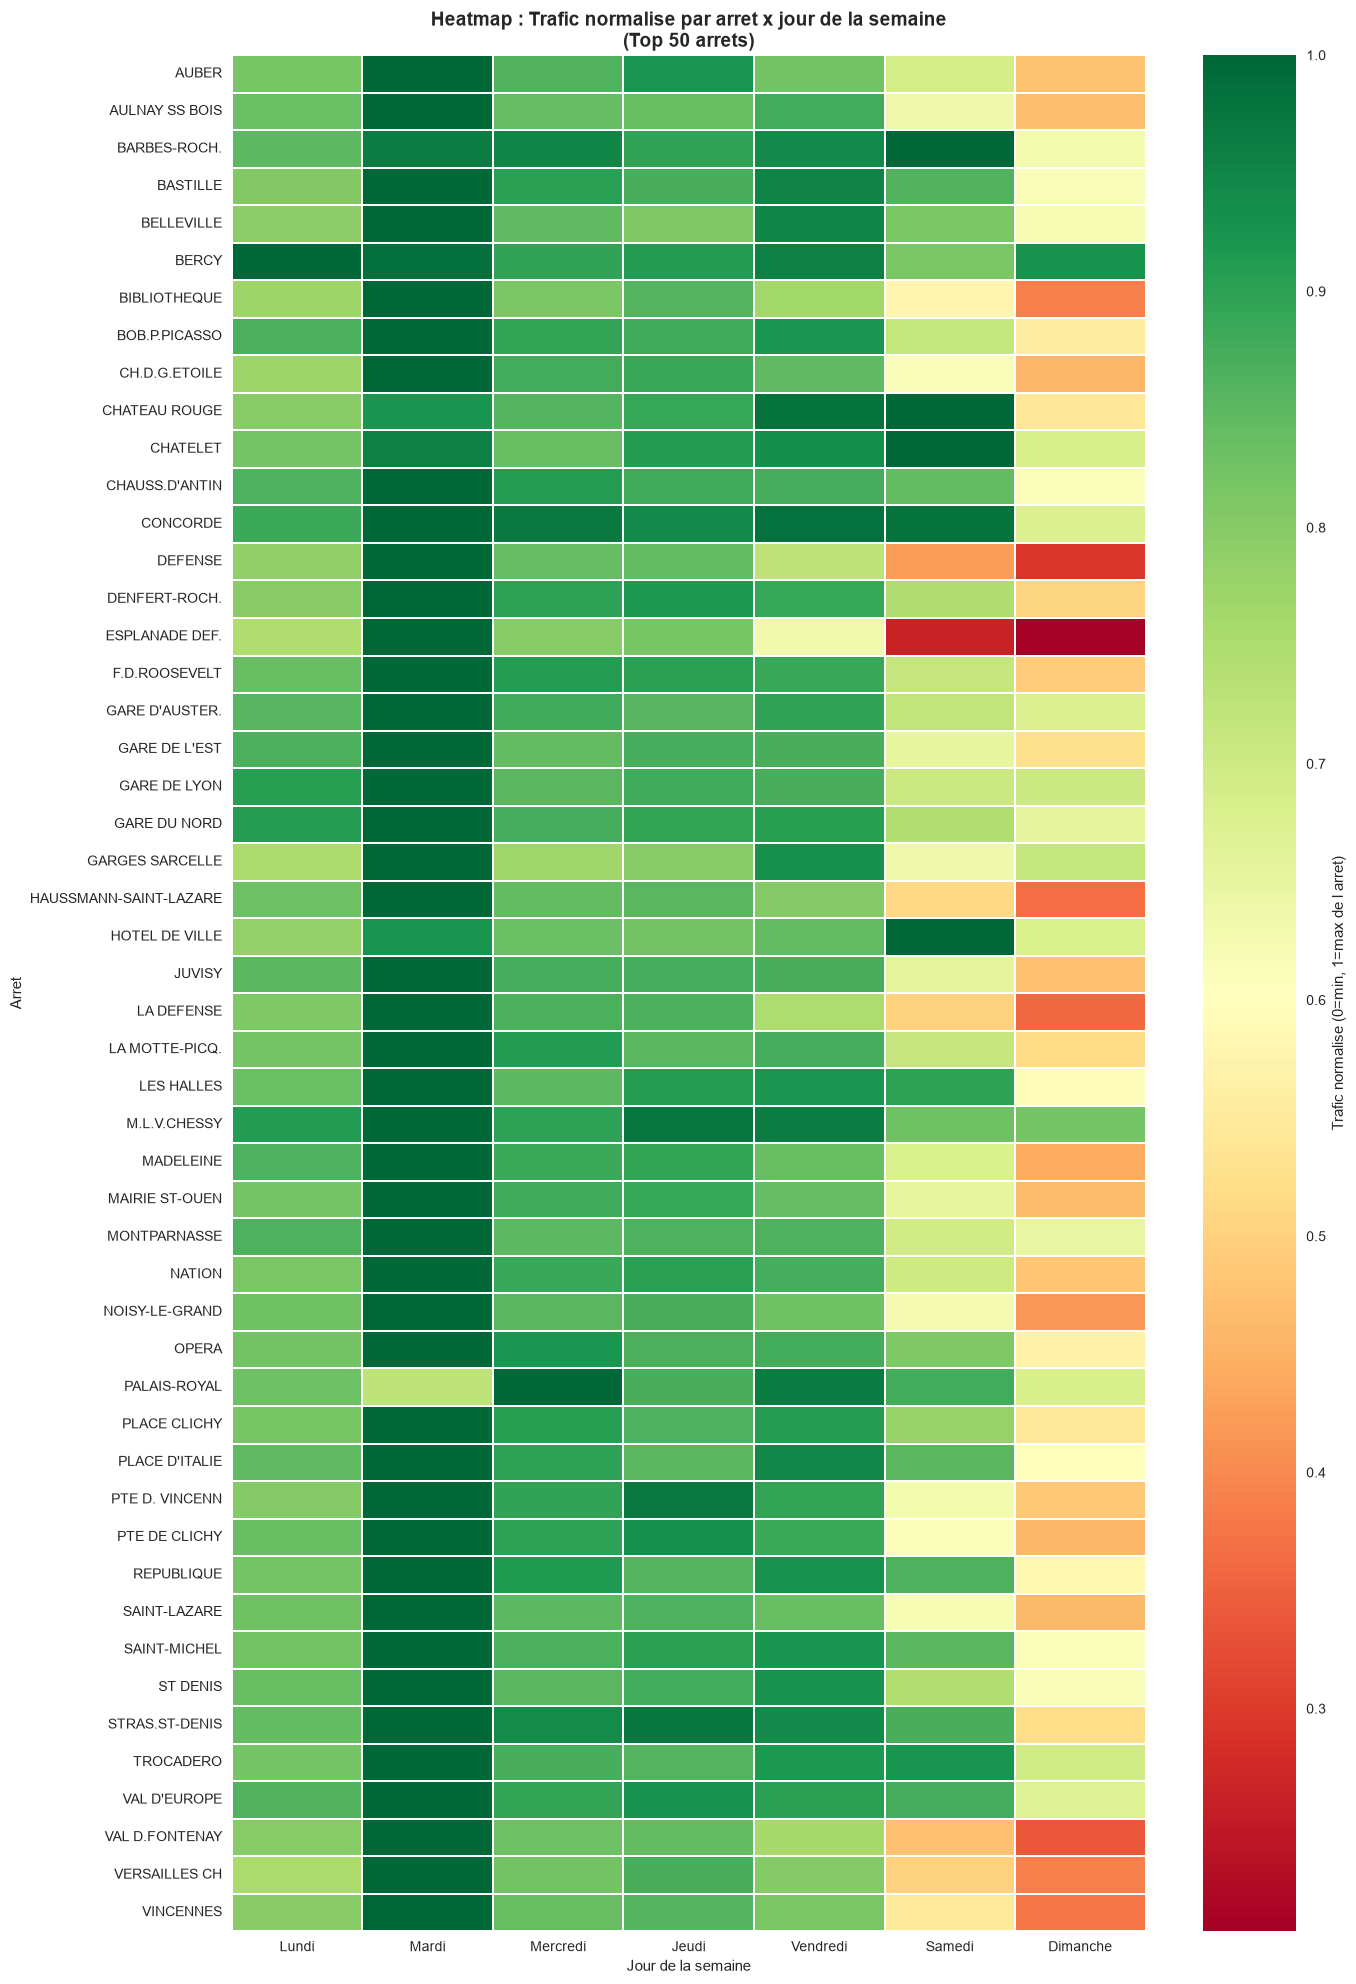

Lecture de la heatmap :
  Ligne rouge semaine + verte week-end  => profil Bureau/Travail
  Ligne rouge week-end                  => profil Touristique
  Ligne uniformement rouge              => profil Hub transport
  Ces profils anticipent les clusters de l Etape 4 !


In [12]:
# ============================================================
# HEATMAP : Arret x Jour de la semaine (Top 50 arrets)
# ============================================================
# POURQUOI UNE HEATMAP ?
# C'est un tableau colore :
# - Chaque ligne = un arret
# - Chaque colonne = un jour de la semaine
# - La couleur = le trafic (rouge = fort, bleu/vert = faible)
#
# Elle permet de voir d'un coup d'oeil les PROFILS d'arrets :
# - Fort en semaine + faible le week-end => arret Bureau/Travail
# - Fort le week-end => arret Touristique (Versailles, Sacre-Coeur)
# - Uniformement fort => arret Hub transport (Chatelet, Gare du Nord)
# Ces profils = futurs clusters de l'Etape 4 !
#
# NORMALISATION : on divise par le max de chaque arret
# POURQUOI : Saint-Lazare a 200x plus de trafic qu'Ablon
# Sans normalisation Saint-Lazare ecraserait tout et on ne verrait rien
# Avec normalisation on compare les PROFILS pas les volumes absolus

top50_arrets = (df.groupby('LIBELLE_ARRET')['NB_VALD']
                  .sum().nlargest(50).index.tolist())

df_top50 = df[df['LIBELLE_ARRET'].isin(top50_arrets)].copy()
df_top50['nom_jour'] = df_top50['JOUR'].dt.day_name()

pivot = (df_top50.groupby(['LIBELLE_ARRET','nom_jour'])['NB_VALD']
                 .sum()
                 .unstack()
                 .reindex(columns=ordre_jours_en))

pivot_norm = pivot.div(pivot.max(axis=1), axis=0)
pivot_norm.columns = noms_fr

plt.figure(figsize=(14, 20))
sns.heatmap(
    pivot_norm,
    cmap='RdYlGn',
    linewidths=0.3,
    annot=False,
    cbar_kws={'label': 'Trafic normalise (0=min, 1=max de l arret)'}
)
plt.title('Heatmap : Trafic normalise par arret x jour de la semaine\n(Top 50 arrets)',
          fontsize=14, fontweight='bold')
plt.xlabel('Jour de la semaine')
plt.ylabel('Arret')
plt.tight_layout()
plt.show()

print('Lecture de la heatmap :')
print('  Ligne rouge semaine + verte week-end  => profil Bureau/Travail')
print('  Ligne rouge week-end                  => profil Touristique')
print('  Ligne uniformement rouge              => profil Hub transport')
print('  Ces profils anticipent les clusters de l Etape 4 !')

---
## PARTIE 3 — Analyse des titres

### Pourquoi ?
Les 7 categories de titres nous donnent des informations sur **qui utilise les transports**.
Comprendre la repartition des titres aide a :
- Identifier les arrets a risque de fraude (taux NON DEFINI eleve)
- Comprendre le profil des usagers de chaque arret
- Detecter des changements de comportement dans le temps

In [13]:
# ============================================================
# EVOLUTION DES PARTS DE MARCHE DES TITRES
# ============================================================
# POURQUOI : voir si les parts evoluent sur les 92 jours
# Imagine R devrait augmenter en septembre (rentree lycees)
# Forfaits courts devrait baisser en septembre (fin tourisme)

trafic_titre_jour = (df.groupby(['JOUR','CATEGORIE_TITRE'])['NB_VALD']
                       .sum().reset_index())

fig = px.area(
    trafic_titre_jour,
    x='JOUR',
    y='NB_VALD',
    color='CATEGORIE_TITRE',
    title='Evolution des validations par categorie de titre (92 jours)',
    labels={'NB_VALD': 'Validations', 'JOUR': 'Date', 'CATEGORIE_TITRE': 'Categorie'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(height=500, hovermode='x unified')
fig.show()

In [14]:
# ============================================================
# PARTS DE MARCHE PAR MOIS
# ============================================================
# Comparer juillet, aout, septembre pour chaque categorie
# Cela nous dira si la composition des voyageurs change selon la saison

df['mois']     = df['JOUR'].dt.month
df['nom_mois'] = df['JOUR'].dt.strftime('%B')

parts_mois = (df.groupby(['mois','nom_mois','CATEGORIE_TITRE'])['NB_VALD']
                .sum().reset_index().sort_values('mois'))

total_par_mois = parts_mois.groupby('mois')['NB_VALD'].transform('sum')
parts_mois['pct'] = (parts_mois['NB_VALD'] / total_par_mois * 100).round(1)

fig = px.bar(
    parts_mois,
    x='nom_mois',
    y='pct',
    color='CATEGORIE_TITRE',
    barmode='group',
    title='Part de marche (%) par categorie de titre et par mois',
    labels={'pct': 'Part (%)', 'nom_mois': 'Mois', 'CATEGORIE_TITRE': 'Categorie'},
    color_discrete_sequence=px.colors.qualitative.Set2,
    text='pct'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=500)
fig.show()

In [15]:
# ============================================================
# ARRETS AVEC LE PLUS DE NON DEFINIS
# ============================================================
# POURQUOI : identifier les arrets suspects
# On a deja vu en SQL que Stade de France est a 14.3%
# Ici on le confirme en Python et on visualise proprement
#
# FORMULE DU TAUX :
# taux = nb_non_defini / total_validations * 100
# (partie / total * 100 = pourcentage)

total_par_arret    = df.groupby('LIBELLE_ARRET')['NB_VALD'].sum()
non_defini_arret   = (df[df['CATEGORIE_TITRE'] == 'NON DEFINI']
                       .groupby('LIBELLE_ARRET')['NB_VALD'].sum())

taux_nd = (non_defini_arret / total_par_arret * 100).fillna(0).round(2)
taux_nd = taux_nd.reset_index()
taux_nd.columns = ['LIBELLE_ARRET', 'taux_non_defini_pct']
taux_nd = taux_nd.sort_values('taux_non_defini_pct', ascending=False).head(20)

fig = px.bar(
    taux_nd,
    x='LIBELLE_ARRET',
    y='taux_non_defini_pct',
    title='TOP 20 Arrets avec le plus de titres NON DEFINIS (%)',
    labels={'taux_non_defini_pct': 'Taux NON DEFINIS (%)', 'LIBELLE_ARRET': 'Arret'},
    color='taux_non_defini_pct',
    color_continuous_scale='Reds',
    text='taux_non_defini_pct'
)
fig.add_hline(y=10, line_dash='dash', line_color='orange',
              annotation_text='Seuil alerte 10%')
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=500, xaxis_tickangle=-45)
fig.show()

---
## PARTIE 4 — Traitement des NON DEFINIS

### Pourquoi ?
On doit decider comment traiter les lignes `CATEGORIE_TITRE = 'NON DEFINI'`
avant de passer au Feature Engineering.

**Decision finale :**
- On les **garde** dans les donnees brutes — utiles pour la detection d'anomalies
- On cree une colonne `is_defini` (True/False) pour les marquer
- On les **exclura** pour construire les features XGBoost (prediction de trafic)

Repartition de is_defini :
is_defini
True     406718
False     61508
Name: count, dtype: int64

Proportion NON DEFINIS : 13.14%


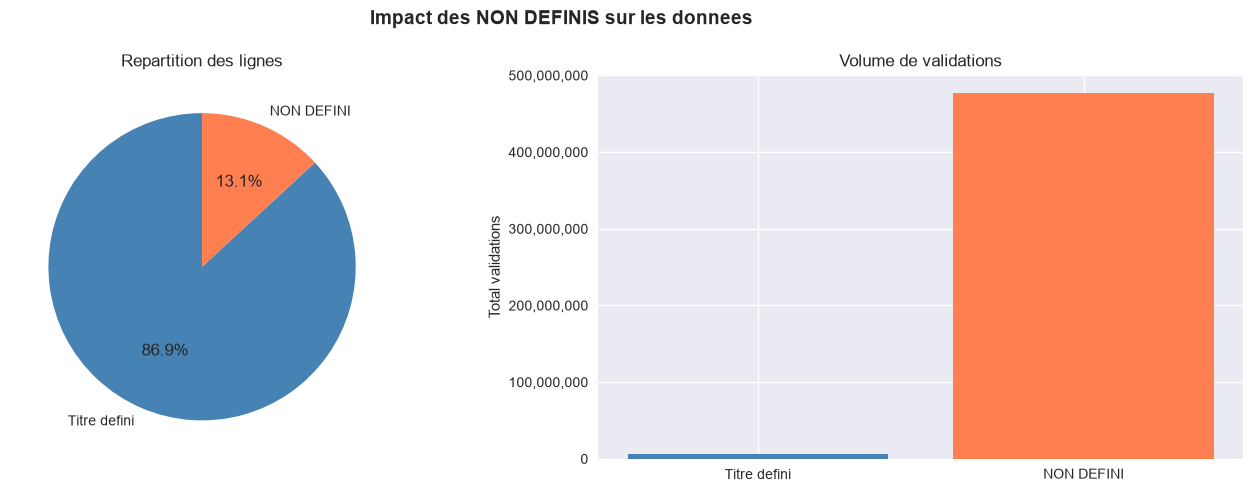

In [16]:
# ============================================================
# CREER LA COLONNE is_defini
# ============================================================
# POURQUOI UN BOOLEEN ?
# Un booleen (True/False) est plus efficace qu'une chaine de texte
# dans les modeles ML. Au lieu de comparer la string 'NON DEFINI'
# a chaque fois, le modele lit juste True ou False.
#
# True  = titre connu et valide (Navigo, Imagine R, etc.)
# False = titre non identifie (NON DEFINI)

df['is_defini'] = df['CATEGORIE_TITRE'] != 'NON DEFINI'

print('Repartition de is_defini :')
vc = df['is_defini'].value_counts()
print(vc)
print(f'\nProportion NON DEFINIS : {(~df["is_defini"]).mean()*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impact des NON DEFINIS sur les donnees', fontsize=14, fontweight='bold')

# Camembert lignes
axes[0].pie(
    vc.values,
    labels=['Titre defini', 'NON DEFINI'],
    autopct='%1.1f%%',
    colors=['steelblue','coral'],
    startangle=90
)
axes[0].set_title('Repartition des lignes')

# Volume de validations
vol = df.groupby('is_defini')['NB_VALD'].sum()
axes[1].bar(['Titre defini','NON DEFINI'], vol.values, color=['steelblue','coral'])
axes[1].set_ylabel('Total validations')
axes[1].set_title('Volume de validations')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{x:,.0f}')
)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# VERIFICATION COMPLETUDE DES ARRETS
# ============================================================
# POURQUOI : certains petits arrets peuvent avoir des trous
# dans les donnees (pas actifs tous les 92 jours)
# Si un arret n'a que 30 jours de donnees :
# - Les lags seront remplis de NULL
# - Le modele XGBoost ne pourra pas les utiliser correctement
# On les identifie maintenant pour les traiter a l'Etape 3

jours_par_arret = (df.groupby('LIBELLE_ARRET')['JOUR']
                     .nunique()
                     .reset_index()
                     .rename(columns={'JOUR': 'nb_jours_actifs'})
                     .sort_values('nb_jours_actifs'))

print('Distribution du nombre de jours actifs par arret :')
print(jours_par_arret['nb_jours_actifs'].describe())

arrets_incomplets = jours_par_arret[jours_par_arret['nb_jours_actifs'] < 60]
print(f'\nArrets avec moins de 60 jours de donnees : {len(arrets_incomplets)}')

if len(arrets_incomplets) > 0:
    print('Ces arrets auront beaucoup de NULL dans les lags => a traiter en Feature Engineering')
    display(arrets_incomplets.head(10))
else:
    print('OK Tous les arrets ont au moins 60 jours de donnees')

fig = px.histogram(
    jours_par_arret,
    x='nb_jours_actifs',
    nbins=30,
    title='Distribution du nombre de jours actifs par arret',
    labels={'nb_jours_actifs': 'Nombre de jours actifs', 'count': 'Nombre d arrets'},
    color_discrete_sequence=['steelblue']
)
fig.add_vline(x=92, line_dash='dash', line_color='green',
              annotation_text='Maximum = 92 jours')
fig.add_vline(x=60, line_dash='dash', line_color='orange',
              annotation_text='Seuil min recommande')
fig.update_layout(height=450)
fig.show()

Distribution du nombre de jours actifs par arret :
count    772.000000
mean      90.275907
std        6.657474
min        3.000000
25%       92.000000
50%       92.000000
75%       92.000000
max       92.000000
Name: nb_jours_actifs, dtype: float64

Arrets avec moins de 60 jours de donnees : 10
Ces arrets auront beaucoup de NULL dans les lags => a traiter en Feature Engineering


,LIBELLE_ARRET,nb_jours_actifs
114,CAMBRONNE,3
518,PERNETY,49
273,GABRIEL PERI,52
15,ANTONY,52
33,AVENUE DU PRESIDENT KENNEDY,54
615,RUNGIS,56
626,SAINT-MICHEL NOTRE DAME,56
553,PORCHEFONTAINE,58
129,CHAMP DE MARS-TOUR EIFFEL,58
214,DOURDAN LA FORE,59


In [18]:
# ============================================================
# RESUME FINAL DE L'EDA
# ============================================================
print('=' * 60)
print("RESUME DE L'EDA — Ce qu'on a appris")
print('=' * 60)
print(f"""
DONNEES
  {len(df):,} lignes | {df['LIBELLE_ARRET'].nunique()} arrets | 92 jours
  Aucune valeur manquante | Aucun doublon
  7 categories de titres

TOP ARRETS
  Saint-Lazare = arret le plus frequente
  Chatelet = 2eme (grand hub de correspondance)
  Les grands arrets concentrent la majorite du trafic

PATTERNS TEMPORELS
  Mardi = jour le plus charge de la semaine
  Dimanche = jour le plus calme (~2x moins que mardi)
  Aout = creux estival | Septembre = reprise rentree
  => justifie les features : is_weekend, jour_semaine, mois

TITRES
  Forfait Navigo domine largement
  Stade de France = 14.3% de NON DEFINIS (le plus eleve)
  Imagine R augmente en septembre (rentree lycees)

POINTS D'ATTENTION POUR L'ETAPE 3
  Colonne is_defini creee (True/False)
  Exclure NON DEFINIS pour les features XGBoost
  Les lags auront des NULL les 7 premiers jours => a gerer
""")
print('OK EDA terminee — on passe a l Etape 3 : Feature Engineering')

RESUME DE L'EDA — Ce qu'on a appris

DONNEES
  468,226 lignes | 772 arrets | 92 jours
  Aucune valeur manquante | Aucun doublon
  7 categories de titres

TOP ARRETS
  Saint-Lazare = arret le plus frequente
  Chatelet = 2eme (grand hub de correspondance)
  Les grands arrets concentrent la majorite du trafic

PATTERNS TEMPORELS
  Mardi = jour le plus charge de la semaine
  Dimanche = jour le plus calme (~2x moins que mardi)
  Aout = creux estival | Septembre = reprise rentree
  => justifie les features : is_weekend, jour_semaine, mois

TITRES
  Forfait Navigo domine largement
  Stade de France = 14.3% de NON DEFINIS (le plus eleve)
  Imagine R augmente en septembre (rentree lycees)

POINTS D'ATTENTION POUR L'ETAPE 3
  Colonne is_defini creee (True/False)
  Exclure NON DEFINIS pour les features XGBoost
  Les lags auront des NULL les 7 premiers jours => a gerer

OK EDA terminee — on passe a l Etape 3 : Feature Engineering
